## objective
1. Load deduplicated dataset
2. Train/test split
3. Verify no text overlap
4. Create TF-IDF features
5. Train baseline models
6. Model comparison
7. Confusion matrices
8. Classification reports
9. Error analysis
10. Initial model selection

In [1]:
import pandas as pd
import numpy as np
import joblib

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score,
    precision_recall_curve,
    average_precision_score
)

In [2]:
# load the data set
df = pd.read_csv("/Users/EXOTISCH TECH/Desktop/Fake-Real-News-Project/data/processed/further_cleaned_news.csv")

In [3]:
print("Data set", df.shape)
print(df.columns.tolist())

Data set (44680, 8)
['Unnamed: 0', 'title', 'text', 'subject', 'date', 'label', 'article_content', 'clean_text']


In [4]:
df.isnull().sum()

Unnamed: 0         0
title              0
text               0
subject            0
date               1
label              0
article_content    0
clean_text         0
dtype: int64

In [5]:
X = df["clean_text"].fillna("").astype(str)
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [6]:
# load the vectorizer
tfidf = joblib.load("/Users/EXOTISCH TECH/Desktop/Fake-Real-News-Project/models/tfidf_vectorizer.pkl")

In [8]:
# check the load
print(tfidf)

TfidfVectorizer(max_df=0.95, max_features=50000, min_df=2, ngram_range=(1, 2),
                sublinear_tf=True)


In [9]:
X_train_tfidf = tfidf.transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [13]:
# save the model

lr_model = joblib.load("/Users/EXOTISCH TECH/Desktop/Fake-Real-News-Project/models/logistic_regression.pkl")
nb_model = joblib.load("/Users/EXOTISCH TECH/Desktop/Fake-Real-News-Project/models/naive_bayes.pkl")
svm_model = joblib.load("/Users/EXOTISCH TECH/Desktop/Fake-Real-News-Project/models/linear_svm.pkl")
rf_model = joblib.load("/Users/EXOTISCH TECH/Desktop/Fake-Real-News-Project/models/random_forest.pkl")

In [14]:
# create a model dictionary
models = {
    "Logistic Regression": lr_model,
    "Naive Bayes": nb_model,
    "Linear SVM": svm_model,
    "Random Forest": rf_model
}

In [15]:
# Generate preedictions
predictions = {}

for name, model in models.items():
    predictions[name] = model.predict(X_test_tfidf)

In [18]:
# for svm
svm_pred = predictions["Linear SVM"]

In [19]:
svm_pred[:5]

array([0, 1, 0, 1, 0])

In [20]:
# classification report
for name, pred in predictions.items():

    print("=" * 70)
    print(name)
    print("=" * 70)

    print(
        classification_report(
            y_test,
            pred,
            target_names=["Fake", "Real"]
        )
    )

Logistic Regression
              precision    recall  f1-score   support

        Fake       0.99      1.00      0.99      4242
        Real       1.00      0.99      0.99      4694

    accuracy                           0.99      8936
   macro avg       0.99      0.99      0.99      8936
weighted avg       0.99      0.99      0.99      8936

Naive Bayes
              precision    recall  f1-score   support

        Fake       0.96      0.97      0.96      4242
        Real       0.97      0.97      0.97      4694

    accuracy                           0.97      8936
   macro avg       0.97      0.97      0.97      8936
weighted avg       0.97      0.97      0.97      8936

Linear SVM
              precision    recall  f1-score   support

        Fake       1.00      1.00      1.00      4242
        Real       1.00      1.00      1.00      4694

    accuracy                           1.00      8936
   macro avg       1.00      1.00      1.00      8936
weighted avg       1.00      1.

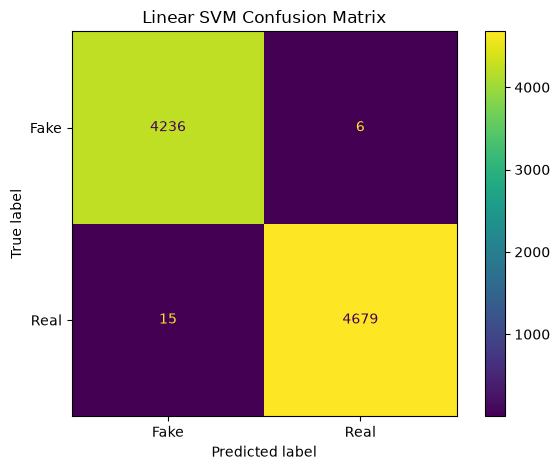

In [21]:
# confusion matrix
cm = confusion_matrix(
    y_test,
    svm_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Fake", "Real"]
)

disp.plot()

plt.title("Linear SVM Confusion Matrix")
plt.tight_layout()
plt.show()


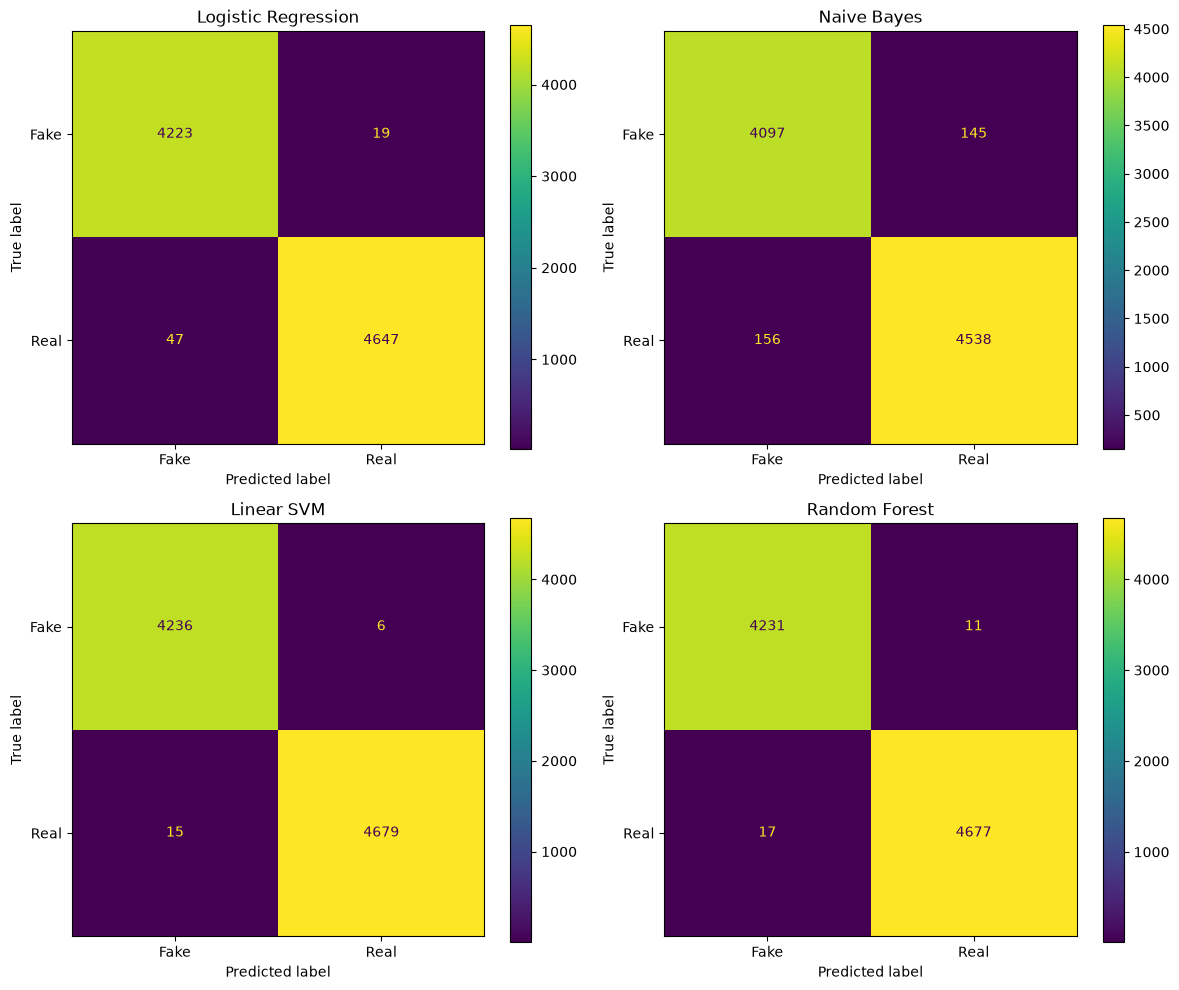

In [22]:
# other models
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for ax, (name, pred) in zip(axes.ravel(), predictions.items()):

    cm = confusion_matrix(y_test, pred)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Fake", "Real"]
    )

    disp.plot(ax=ax)

    ax.set_title(name)

plt.tight_layout()
plt.show()

In [23]:
# ROC_AUC
scores = {}

scores["Logistic Regression"] = lr_model.predict_proba(
    X_test_tfidf
)[:, 1]

scores["Naive Bayes"] = nb_model.predict_proba(
    X_test_tfidf
)[:, 1]

scores["Linear SVM"] = svm_model.decision_function(
    X_test_tfidf
)

scores["Random Forest"] = rf_model.predict_proba(
    X_test_tfidf
)[:, 1]


In [25]:
# calculate the AUC
auc_results = {}

for name, score in scores.items():

    auc_results[name] = roc_auc_score(
        y_test,
        score
    )

auc_results

{'Logistic Regression': 0.9996721064157058,
 'Naive Bayes': 0.9930097246135835,
 'Linear SVM': 0.9999635394789098,
 'Random Forest': 0.9999179889380989}

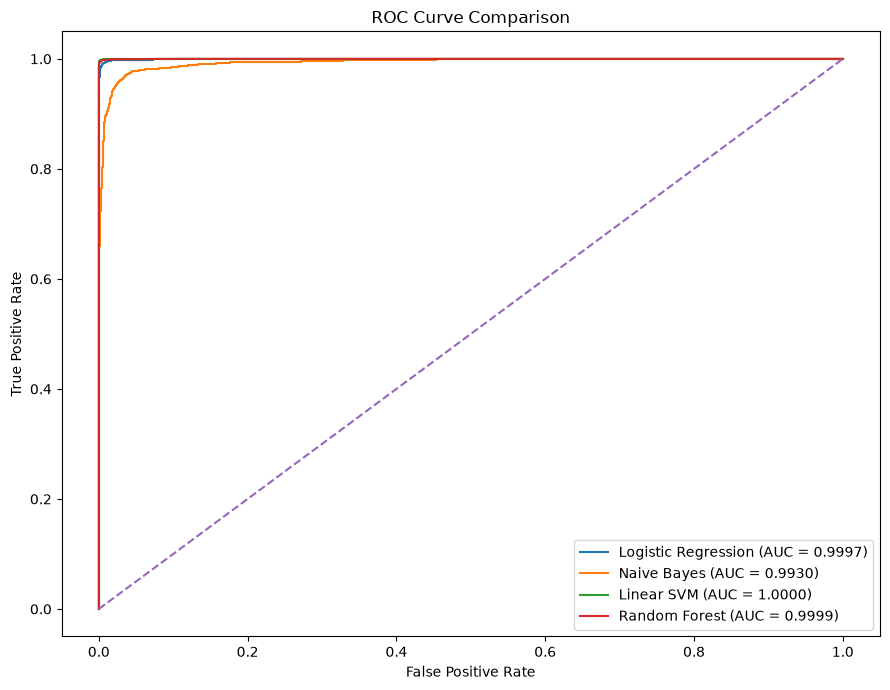

In [26]:
# plot the curve
plt.figure(figsize=(9, 7))

for name, score in scores.items():

    fpr, tpr, _ = roc_curve(
        y_test,
        score
    )

    auc = roc_auc_score(
        y_test,
        score
    )

    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC = {auc:.4f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.tight_layout()
plt.show()

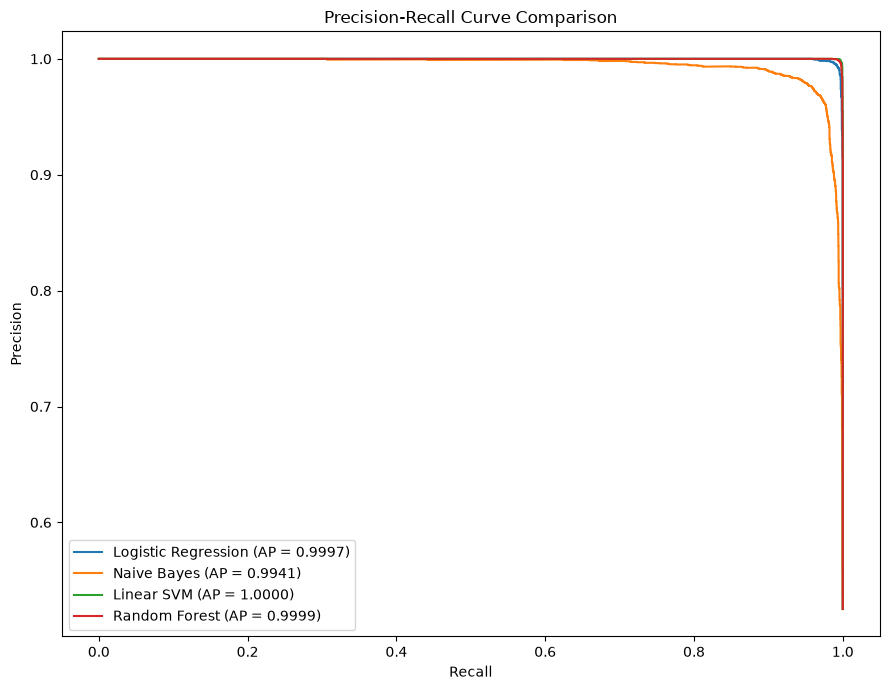

In [27]:
# pricision recall curve
plt.figure(figsize=(9, 7))

for name, score in scores.items():

    precision, recall, _ = precision_recall_curve(
        y_test,
        score
    )

    ap = average_precision_score(
        y_test,
        score
    )

    plt.plot(
        recall,
        precision,
        label=f"{name} (AP = {ap:.4f})"
    )

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve Comparison")
plt.legend()
plt.tight_layout()
plt.show()

In [28]:
# complete evaluation table
evaluation_results = []

for name, pred in predictions.items():

    evaluation_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred),
        "Recall": recall_score(y_test, pred),
        "F1 Score": f1_score(y_test, pred),
        "ROC AUC": auc_results[name]
    })

evaluation_df = pd.DataFrame(evaluation_results)

evaluation_df.sort_values(
    by="F1 Score",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
2,Linear SVM,0.997650,0.998719,0.996804,0.997761,0.999964
3,Random Forest,0.996867,0.997654,0.996378,0.997016,0.999918
0,Logistic Regression,0.992614,0.995928,0.989987,0.992949,0.999672
1,Naive Bayes,0.966316,0.969037,0.966766,0.967900,0.993010


In [30]:
evaluation_df.to_csv(
    "/Users/EXOTISCH TECH/Desktop/Fake-Real-News-Project/reports/model_evaluation.csv",
    index=False
)

In [31]:
# Error Analysis
error_analysis = df.loc[
    X_test.index
].copy()

error_analysis["prediction"] = svm_pred

error_analysis["correct"] = (
    error_analysis["label"]
    == error_analysis["prediction"]
)

In [32]:
misclassified = error_analysis[
    error_analysis["correct"] == False
]

In [33]:
print(
    "Number of misclassified articles:",
    len(misclassified)
)

Number of misclassified articles: 21


In [ ]:
# dataframe of the misclassified class
misclassified[
    ["title", "subject", "date", "label", "prediction"]
].head(20)

,title,subject,date,label,prediction
18316,Factbox: Trump plan to dismantle 'Dreamer' pro...,politicsNews,2017-09-05,0,1
34585,WHOA! FRANCE’S CONSERVATIVE PRESIDENTIAL CANDI...,politics,2017-02-21,1,0
37688,Conservatives bristle as Trump backs off Clint...,politicsNews,2016-11-23,0,1
44031,Hillary Clinton's 'What Happened' fends off O'...,politicsNews,2017-09-28,0,1
12418,2012: JUSTICE KENNEDY READ A SCATHING DISSENTI...,politics,2015-06-14,1,0
10101,BREAKING: LIBERAL HEADS WILL EXPLODE When They...,politics,2016-12-14,1,0
23758,WHAT THE U.S. Would Save If Trump Cut Aid To U...,politics,2017-12-29,1,0
8537,STUNNING! FIRST LADY MELANIA TRUMP Wears Red T...,politics,2017-04-06,1,0
1208,OBAMA USES LABOR DAY TO HARM PRIVATE SECTOR WI...,Government News,2015-09-07,1,0
23517,Obama statement on death of Supreme Court Just...,politicsNews,2016-02-14,0,1


In [35]:
# Error by subject
misclassified["subject"].value_counts()

subject
politics           9
politicsNews       6
Government News    4
left-news          1
News               1
Name: count, dtype: int64

In [36]:
pd.crosstab(
    misclassified["subject"],
    misclassified["label"]
)

label,0,1
subject,,
Government News,0,4
News,0,1
left-news,0,1
politics,0,9
politicsNews,6,0


In [37]:
# check for duplicate
print(
    "Duplicate rows:",
    df.duplicated().sum()
)

Duplicate rows: 0


In [38]:
print(
    "Duplicate clean texts:",
    df["clean_text"].duplicated().sum()
)

Duplicate clean texts: 5586


In [39]:
train_texts = set(X_train)

test_texts = set(X_test)

overlap = train_texts.intersection(test_texts)

print("Exact text overlap:", len(overlap))

Exact text overlap: 1710


In [41]:
# there is a problem
train_overlap = X_train[
    X_train.isin(X_test)
]

print("Training texts appearing in test:", len(train_overlap))

Training texts appearing in test: 1899


In [42]:
overlap_texts = set(X_train).intersection(set(X_test))

print("Unique overlapping texts:", len(overlap_texts))

Unique overlapping texts: 1710


In [43]:
print("Training size:", len(X_train))
print("Test size:", len(X_test))
print("Overlap:", len(overlap_texts))

Training size: 35744
Test size: 8936
Overlap: 1710


In [44]:
for text in list(overlap_texts)[:5]:
    print("=" * 80)
    print(text[:1000])

new book lib writer radio host send shock wave democrat party maybe queen incompetence popular hoped socialist party america aka former democrat party republican get riled thought democratic frontrunner hillary clinton ascending presidency people left lock horn clinton often enough suggest team hillary still long way go shored traditional base progressive votersa controversial book cover latest flashpoint lay bare division democratic base clinton candidacy forthcoming book turn nation magazine contributing editor doug henwood critique former secretary state decadeslong political career calling foreign policy position purported connection bigmoney interest among contentious pointsand book cover flamboyant illustration featuring stoic hillary clinton bloodred dress pointing gun reader sparked heated debate among supporter detractorssalon editor joan walsh former obama speechwriter jon lovett called drawing gross leftist rag saloncom say new hillary clinton book stink bomb liberal certain

In [45]:
overlap_df = df[
    df["clean_text"].isin(overlap_texts)
][["title", "clean_text", "label", "subject", "date"]]

overlap_df.head(20)

,title,clean_text,label,subject,date
15,OVER 100 COLLEGES WILL HOLD SEPARATE GRADUATIO...,college hold separate graduation ceremony gay ...,1,politics,2016-04-29
26,WALMART WILL MELT CLASS RINGS WITH CONFEDERATE...,walmart melt class ring confederate flag video...,1,Government News,2015-07-11
34,STUNNING! FORMER DISNEY TECH WORKER’S Emotiona...,stunning former disney tech worker’s emotional...,1,Government News,2016-02-25
39,DEMOCRATS THREATEN KIDS EDUCATION: CHICAGO TEA...,democrat threaten kid education chicago teache...,1,left-news,2015-06-24
56,BRILLIANT TRUMP ADVISER: “The Extreme Media” H...,brilliant trump adviser “the extreme media” go...,1,left-news,2017-08-08
62,Utah Ranchers Vow to Stand Up to Government Ab...,utah rancher vow stand government abuse despit...,1,US_News,2016-04-05
64,MAINSTREAM MEDIA IGNORES MASSIVE PROTEST Again...,mainstream medium ignores massive protest obam...,1,Government News,2015-10-13
66,DEVASTATING 30 SECOND Commercial Shows Scary T...,devastating second commercial show scary truth...,1,politics,2016-05-26
76,ESPIONAGE ACT VIOLATION? HILLARY EXPOSES Names...,espionage act violation hillary expose name hi...,1,politics,2016-06-05
79,DIRTY JOBS’ MIKE ROWE: Great Opportunities Out...,dirty jobs’ mike rowe great opportunity people...,1,left-news,2016-12-27


In [46]:
overlap_df.groupby("clean_text")["label"].nunique().value_counts()

label
1    1710
Name: count, dtype: int64

In [47]:
print("Training size:", len(X_train))
print("Test size:", len(X_test))
print("Unique overlapping texts:", len(overlap_texts))

Training size: 35744
Test size: 8936
Unique overlapping texts: 1710


In [48]:
overlap_df.head(20)

,title,clean_text,label,subject,date
15,OVER 100 COLLEGES WILL HOLD SEPARATE GRADUATIO...,college hold separate graduation ceremony gay ...,1,politics,2016-04-29
26,WALMART WILL MELT CLASS RINGS WITH CONFEDERATE...,walmart melt class ring confederate flag video...,1,Government News,2015-07-11
34,STUNNING! FORMER DISNEY TECH WORKER’S Emotiona...,stunning former disney tech worker’s emotional...,1,Government News,2016-02-25
39,DEMOCRATS THREATEN KIDS EDUCATION: CHICAGO TEA...,democrat threaten kid education chicago teache...,1,left-news,2015-06-24
56,BRILLIANT TRUMP ADVISER: “The Extreme Media” H...,brilliant trump adviser “the extreme media” go...,1,left-news,2017-08-08
62,Utah Ranchers Vow to Stand Up to Government Ab...,utah rancher vow stand government abuse despit...,1,US_News,2016-04-05
64,MAINSTREAM MEDIA IGNORES MASSIVE PROTEST Again...,mainstream medium ignores massive protest obam...,1,Government News,2015-10-13
66,DEVASTATING 30 SECOND Commercial Shows Scary T...,devastating second commercial show scary truth...,1,politics,2016-05-26
76,ESPIONAGE ACT VIOLATION? HILLARY EXPOSES Names...,espionage act violation hillary expose name hi...,1,politics,2016-06-05
79,DIRTY JOBS’ MIKE ROWE: Great Opportunities Out...,dirty jobs’ mike rowe great opportunity people...,1,left-news,2016-12-27


In [49]:
overlap_df.groupby("clean_text")["label"].nunique().value_counts()

label
1    1710
Name: count, dtype: int64

In [50]:
print("Total rows:", len(df))

print(
    "Unique clean texts:",
    df["clean_text"].nunique()
)

print(
    "Duplicate clean texts:",
    df["clean_text"].duplicated().sum()
)

Total rows: 44680
Unique clean texts: 39094
Duplicate clean texts: 5586


In [51]:
duplicate_mask = df["clean_text"].duplicated(
    keep=False
)

duplicate_df = df.loc[
    duplicate_mask
].sort_values("clean_text")

duplicate_df[
    ["title", "clean_text", "label", "subject", "date"]
].head(20)

,title,clean_text,label,subject,date
23505,ABC NEWS: Emails Show Hillary’s Top Aide Arran...,abc news email show hillary’s top aide arrange...,1,left-news,2016-08-28
43123,ABC NEWS: Emails Show Hillary’s Top Aide Arran...,abc news email show hillary’s top aide arrange...,1,politics,2016-08-28
13820,ABC NEWS Gets DESTROYED On Twitter For Waiting...,abc news get destroyed twitter waiting several...,1,left-news,2017-12-01
34991,ABC NEWS Gets DESTROYED On Twitter For Waiting...,abc news get destroyed twitter waiting several...,1,politics,2017-12-01
5244,ABC NEWS REPORTS: Las Vegas Massacre Suspect’s...,abc news report la vega massacre suspect’s har...,1,politics,2017-10-25
22410,ABC NEWS REPORTS: Las Vegas Massacre Suspect’s...,abc news report la vega massacre suspect’s har...,1,left-news,2017-10-25
7949,ABC News Suspend Anchor Brian Ross Over Fake N...,abc news suspend anchor brian ross fake news r...,1,Middle-east,2017-12-05
9058,ABC News Suspend Anchor Brian Ross Over Fake N...,abc news suspend anchor brian ross fake news r...,1,US_News,2017-12-05
15316,ABC Producing Comedy Involving Illegal Alien F...,abc producing comedy involving illegal alien f...,1,left-news,2017-09-22
42758,ABC Producing Comedy Involving Illegal Alien F...,abc producing comedy involving illegal alien f...,1,politics,2017-09-22


In [52]:
# check for conflicting labels
label_conflicts = (
    df.groupby("clean_text")["label"]
      .nunique()
)

print(
    "Texts appearing with multiple labels:",
    (label_conflicts > 1).sum()
)

Texts appearing with multiple labels: 0


In [53]:
# create a deduplicated data set
df_model = df.drop_duplicates(
    subset="clean_text",
    keep="first"
).copy()

print("Original shape:", df.shape)
print("Deduplicated shape:", df_model.shape)

print(
    "Remaining duplicate texts:",
    df_model["clean_text"].duplicated().sum()
)

Original shape: (44680, 8)
Deduplicated shape: (39094, 8)
Remaining duplicate texts: 0


In [54]:
# check distribution
print("Class distribution:")
print(df_model["label"].value_counts())

print("\nClass proportions:")
print(df_model["label"].value_counts(normalize=True))

Class distribution:
label
0    21194
1    17900
Name: count, dtype: int64

Class proportions:
label
0    0.542129
1    0.457871
Name: proportion, dtype: float64


In [55]:
from sklearn.model_selection import train_test_split

X = df_model["clean_text"].fillna("").astype(str)
y = df_model["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training size:", len(X_train))
print("Test size:", len(X_test))

Training size: 31275
Test size: 7819


In [56]:
overlap = set(X_train).intersection(set(X_test))

print("Exact text overlap:", len(overlap))

Exact text overlap: 0


In [57]:
# Rebuuilt TF_IDF


In [58]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=100000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

In [59]:
# fit the training data
X_train_tfidf = tfidf.fit_transform(X_train)

In [60]:
# transform the test data
X_test_tfidf = tfidf.transform(X_test)

In [61]:
# check the matrices
print("X_train TF-IDF:", X_train_tfidf.shape)
print("X_test TF-IDF:", X_test_tfidf.shape)

X_train TF-IDF: (31275, 100000)
X_test TF-IDF: (7819, 100000)


In [62]:
# import the models and metrics
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

In [63]:
# Define the models
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42
    ),

    "Naive Bayes": MultinomialNB(),

    "Linear SVM": LinearSVC(
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    )
}

In [64]:
# trian the model
results = []

for name, model in models.items():

    print(f"Training {name}...")

    model.fit(X_train_tfidf, y_train)

    y_pred = model.predict(X_test_tfidf)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred)
    })

print("Training and evaluation completed.")

Training Logistic Regression...
Training Naive Bayes...
Training Linear SVM...
Training Random Forest...
Training and evaluation completed.


In [65]:
# create the comparison table
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="F1 Score",
    ascending=False
).reset_index(drop=True)

results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Linear SVM,0.997314,0.998320,0.995810,0.997063
1,Random Forest,0.993222,0.996621,0.988547,0.992568
2,Logistic Regression,0.992071,0.996332,0.986313,0.991297
3,Naive Bayes,0.966364,0.966264,0.960056,0.963150


In [66]:
# save the result
results_df.to_csv(
    "/Users/EXOTISCH TECH/Desktop/Fake-Real-News-Project/reports/model_comparison_leakage_free.csv",
    index=False
)

In [67]:
# save the new data
df_model.to_csv(
    "/Users/EXOTISCH TECH/Desktop/Fake-Real-News-Project/data/processed/news_deduplicated.csv",
    index=False
)

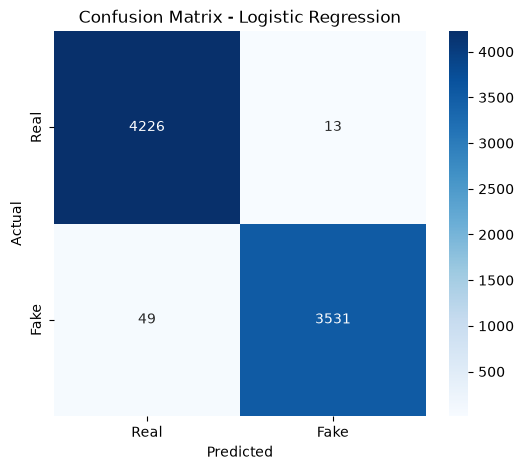

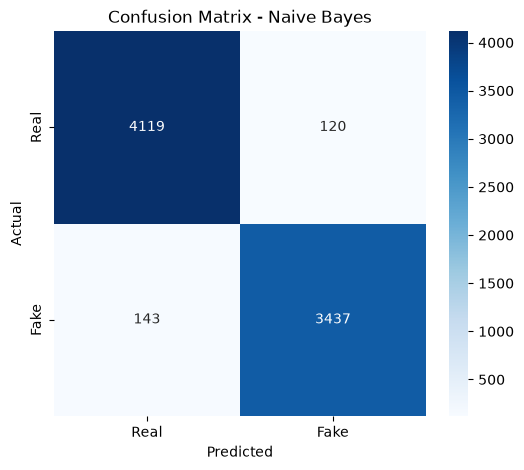

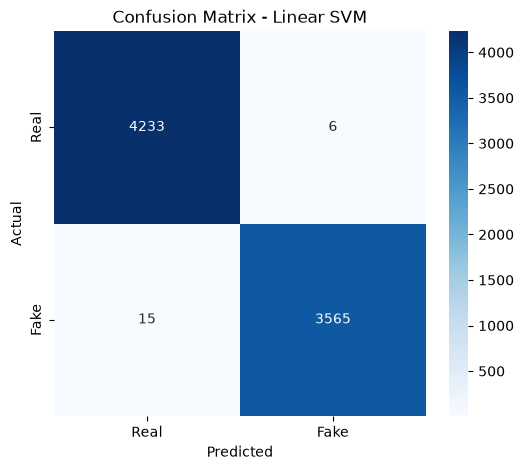

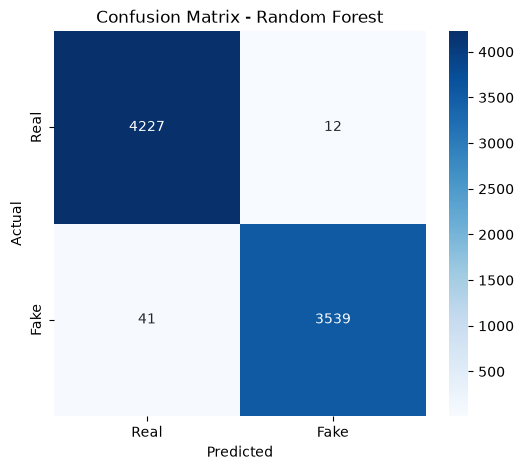

In [69]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

for name, model in models.items():

    y_pred = model.predict(X_test_tfidf)

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(6, 5))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Real", "Fake"],
        yticklabels=["Real", "Fake"]
    )

    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

In [70]:
# classification
from sklearn.metrics import classification_report

for name, model in models.items():

    y_pred = model.predict(X_test_tfidf)

    print("=" * 70)
    print(name)
    print("=" * 70)

    print(
        classification_report(
            y_test,
            y_pred,
            target_names=["Real", "Fake"]
        )
    )

Logistic Regression
              precision    recall  f1-score   support

        Real       0.99      1.00      0.99      4239
        Fake       1.00      0.99      0.99      3580

    accuracy                           0.99      7819
   macro avg       0.99      0.99      0.99      7819
weighted avg       0.99      0.99      0.99      7819

Naive Bayes
              precision    recall  f1-score   support

        Real       0.97      0.97      0.97      4239
        Fake       0.97      0.96      0.96      3580

    accuracy                           0.97      7819
   macro avg       0.97      0.97      0.97      7819
weighted avg       0.97      0.97      0.97      7819

Linear SVM
              precision    recall  f1-score   support

        Real       1.00      1.00      1.00      4239
        Fake       1.00      1.00      1.00      3580

    accuracy                           1.00      7819
   macro avg       1.00      1.00      1.00      7819
weighted avg       1.00      1.

# Final Summary Model Evaluation

## Evaluation Overview

This notebook evaluated the baseline machine learning models for fake news classification using TF-IDF features.

An initial investigation identified a potential data leakage issue in the original train-test split. The dataset contained **5,586 duplicate `clean_text` records**, including **1,710 exact text overlaps between the training and test sets**.

To ensure a reliable evaluation, duplicate articles were removed before creating a new stratified train-test split.

### Leakage-Controlled Dataset

- Original dataset: **44,680 records**
- Deduplicated dataset: **39,094 records**
- Remaining duplicate texts: **0**
- Training set: **31,275 records**
- Test set: **7,819 records**
- Exact text overlap between training and test sets: **0**
- Class 0: **54.21%**
- Class 1: **45.79%**

The absence of conflicting labels among duplicate texts confirmed that deduplication could be performed without introducing label ambiguity.

## TF-IDF Representation

A TF-IDF vectorizer was fitted **only on the training data** and subsequently used to transform the test data.

- Training TF-IDF matrix: **31,275 × 100,000**
- Test TF-IDF matrix: **7,819 × 100,000**

This approach prevents information from the test set from influencing the learned vocabulary or IDF weights.

## Baseline Model Performance

| Model | Accuracy | Precision | Recall | F1 Score |
|---|---:|---:|---:|---:|
| **Linear SVM** | **99.7314%** | **99.8320%** | **99.5810%** | **99.7063%** |
| Random Forest | 99.3222% | 99.6621% | 98.8547% | 99.2568% |
| Logistic Regression | 99.2071% | 99.6332% | 98.6313% | 99.1297% |
| Naive Bayes | 96.6364% | 96.6264% | 96.0056% | 96.3150% |

## Key Findings

- **Linear SVM achieved the best overall baseline performance**, with an F1 score of **99.71%**.
- Random Forest and Logistic Regression also demonstrated strong classification performance.
- Naive Bayes performed well but was substantially weaker than the other three models.
- Removing duplicate articles and eliminating train-test text overlap caused only a small change in performance, suggesting that the extremely strong results were not primarily caused by the identified duplicate-text leakage.
- The dataset remains reasonably balanced after deduplication, with class 0 representing **54.21%** and class 1 representing **45.79%**.

## Conclusion

The baseline evaluation indicates that **Linear SVM is currently the strongest candidate model** for the fake news classification task.

However, these results represent baseline performance and should not yet be considered the final model. Further analysis will include **confusion matrix examination, classification reports, error analysis, and hyperparameter tuning** to determine whether the model can be improved and whether its performance remains robust on difficult or ambiguous news articles.

The best-performing model from this stage will be carried forward as the primary candidate for subsequent optimization and eventual deployment.